In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [38]:
df = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\acidentes_pbic_somas.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df.shape)


Shape inicial: (1678326, 53)


In [39]:
# TARGET (MORTE)
# =============================

df["target_grave"] = (
    (df["mortos"] > 0) | (df["feridos_graves"] > 0)
).astype(int)

print(df["target_grave"].value_counts(normalize=True))

target_grave
0    0.825025
1    0.174975
Name: proportion, dtype: float64


In [40]:
# KM
df["km"] = (
    df["km"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["km"] = pd.to_numeric(df["km"], errors="coerce")

# Latitude / Longitude
df["latitude"] = (
    df["latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["longitude"] = (
    df["longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# Idade veículo
df["idade_veiculo"] = 2025 - df["ano_fabricacao_veiculo"]

In [41]:
coords = df[['latitude', 'longitude']].dropna()
kmeans = KMeans(n_clusters=100, random_state=42).fit(coords)
df['cluster_localizacao'] = kmeans.predict(df[['latitude', 'longitude']])

In [42]:
df['veiculo_velho'] = (df['idade_veiculo'] > 15).astype(int)
# No LightGBM, isso pode virar uma nova categoria ou feature combinada

In [43]:
df["km_bin"] = (df["km"] // 5) * 5

In [44]:
features = [
    "uf",
    "br",
    "km_bin",
    "hora",
    #'horario',
    "mes",
    "dia_semana",
    'dia_mes',
    "tipo_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo", #*
    "tipo_veiculo",
    #"idade",
    #'sexo',
    "idade_veiculo",
    #'cluster_localizacao',
    'latitude', 
    'longitude',
    'regional', 
    #'marca',
    'Fabricante',
    #'Modelo'
]

# features = [
#     "hora",
#     "mes",
#     "dia_semana",
#     "tipo_acidente",
#     "fase_dia",
#     "condicao_metereologica",
#     "tipo_pista",
#     "tracado_via",
#     "uso_solo",
#     "tipo_veiculo",
#     "idade",
#     "idade_veiculo",
#     "Fabricante",
#     "Modelo"
# ]


df = df.dropna(subset=["target_grave"])

for col in features:
    
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
        
    else:
        df[col] = df[col].fillna("Desconhecido")

categoricas = df[features].select_dtypes(include="object").columns

for col in categoricas:
    df[col] = df[col].astype("category")

C:\Users\fause\AppData\Local\Temp\ipykernel_5764\498528044.py:57: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df[features].select_dtypes(include="object").columns


In [45]:
X = df[features]
y = df["target_grave"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 importante (balanceamento)
)

In [46]:
import lightgbm as lgb

# modelo = lgb.LGBMRegressor(
#     n_estimators=400,
#     learning_rate=0.05,
#     num_leaves=64,
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     max_bin=512

# )

# scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
# print(scale_pos_weight)
# modelo = lgb.LGBMRegressor(
#     n_estimators=800,          # mais árvores
#     learning_rate=0.03,        # aprendizado mais suave
#     num_leaves=128,            # mais capacidade
#     max_depth=-1,              # sem limite explícito
#     min_child_samples=40,      # evita overfitting
#     subsample=0.8,             # bagging
#     colsample_bytree=0.8,      # feature sampling
#     scale_pos_weight=scale_pos_weight,
#     reg_alpha=0.5,             # regularização L1
#     reg_lambda=0.5,            # regularização L2
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     max_bin=512
# )

# modelo.fit(X_train, y_train)

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(scale_pos_weight)
modelo = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    #scale_pos_weight=scale_pos_weight,
    scale_pos_weight=2.5,
    reg_alpha=0.3,
    reg_lambda=0.3,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)

4.715100539730646
[LightGBM] [Info] Number of positive: 234932, number of negative: 1107728
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007123 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1504
[LightGBM] [Info] Number of data points in the train set: 1342660, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174975 -> initscore=-1.550770
[LightGBM] [Info] Start training from score -1.550770


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.05
,n_estimators,600
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


[LightGBM] [Info] Number of positive: 187946, number of negative: 886182
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006875 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1506
[LightGBM] [Info] Number of data points in the train set: 1074128, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174975 -> initscore=-1.550768
[LightGBM] [Info] Start training from score -1.550768
[LightGBM] [Info] Number of positive: 187946, number of negative: 886182
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1505
[LightGBM] [Info] Number of data points in the train set: 1074128, number of used features: 19
[LightGBM]

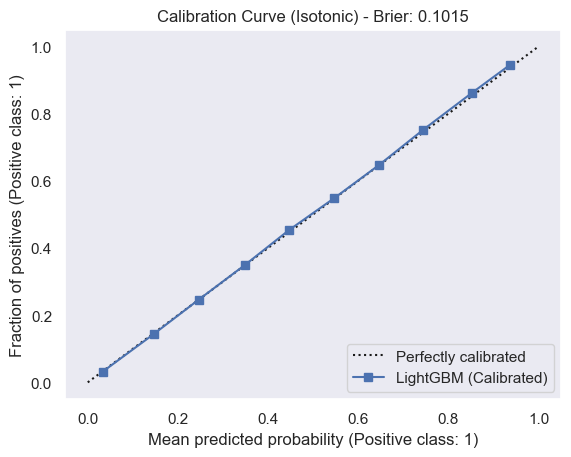

In [47]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Assuming 'lgbm_model' is your initialized base LightGBM model
# (e.g., lgbm_model = LGBMClassifier(...))
# and you have your X_train, y_train, X_test, y_test ready

# 1. Initialize the calibrator
# 'isotonic' is highly recommended for large datasets and fixes the "belly" shape well.
# If your dataset is very small, 'sigmoid' (Platt Scaling) might be preferred.
calibrated_lgbm = CalibratedClassifierCV(estimator=modelo, method='isotonic', cv=5)

# 2. Fit the calibrated model (This trains the base model AND calibrates it)
calibrated_lgbm.fit(X_train, y_train)

# 3. Get the new, calibrated probabilities for the test set
calibrated_proba = calibrated_lgbm.predict_proba(X_test)[:, 1]

# 4. Calculate the new Brier Score to see the improvement
new_brier = brier_score_loss(y_test, calibrated_proba)
print(f"New Brier Score: {new_brier:.4f}")

# 5. Plot the new Calibration Curve to compare the visual results
disp_calib = CalibrationDisplay.from_predictions(
    y_test, 
    calibrated_proba, 
    n_bins=10, 
    name='LightGBM (Calibrated)'
)

plt.title(f'Calibration Curve (Isotonic) - Brier: {new_brier:.4f}')
plt.grid(False) # Prevents grid overlap
plt.show()

In [48]:
pred = modelo.predict(X_test)
proba = modelo.predict_proba(X_test)[:,1]

print("\nClassification Report:\n")
print(classification_report(y_test, pred))

print("ROC AUC:", roc_auc_score(y_test, proba))


Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.88      0.90    276933
           1       0.53      0.61      0.56     58733

    accuracy                           0.84    335666
   macro avg       0.72      0.75      0.73    335666
weighted avg       0.85      0.84      0.84    335666

ROC AUC: 0.8610699347780926


In [49]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Definir a estratégia de validação (5 ou 10 folds é o padrão)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definir as métricas que queremos monitorar
# 'f1_weighted' é bom para classes desbalanceadas, 
# 'roc_auc' mede a capacidade de separação
metricas = ['precision', 'recall', 'f1', 'roc_auc']

print(f"Iniciando Cross-Validation com {skf.get_n_splits()} folds...\n")

# 3. Executar o Cross-Validation
# Nota: Passamos o X e y completos (ou X_train e y_train)
cv_results = cross_validate(
    modelo, X, y, 
    cv=skf, 
    scoring=metricas, 
    n_jobs=-1, 
    return_train_score=False
)

# 4. Exibir os resultados médios
print("-" * 30)
print("RESULTADOS MÉDIOS (CV):")
print(f"ROC AUC:   {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")
print(f"Recall:    {cv_results['test_recall'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"F1-Score:  {cv_results['test_f1'].mean():.4f}")
print("-" * 30)

Iniciando Cross-Validation com 5 folds...

------------------------------
RESULTADOS MÉDIOS (CV):
ROC AUC:   0.8613 (+/- 0.0006)
Recall:    0.6059
Precision: 0.5269
F1-Score:  0.5636
------------------------------


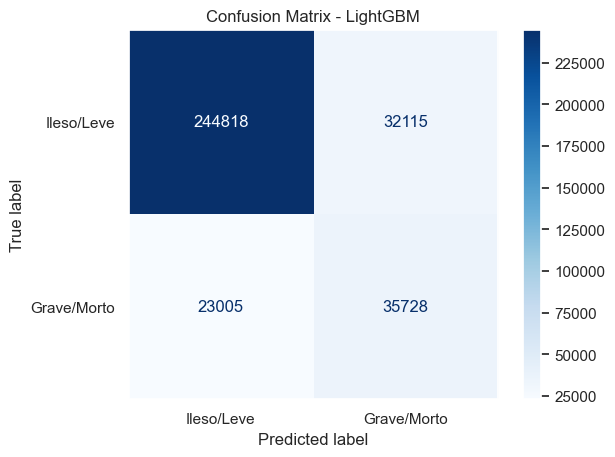

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Utilizando o y_test e pred do seu modelo treinado
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ileso/Leve', 'Grave/Morto'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - LightGBM')
plt.grid(False) # Evita sobreposição de grades
plt.show()

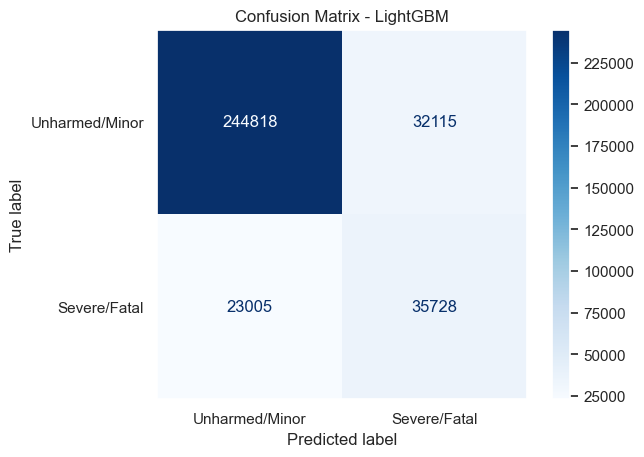

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Using y_test and pred from your trained model
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unharmed/Minor', 'Severe/Fatal'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - LightGBM')
plt.grid(False) # Prevents grid overlap
plt.show()

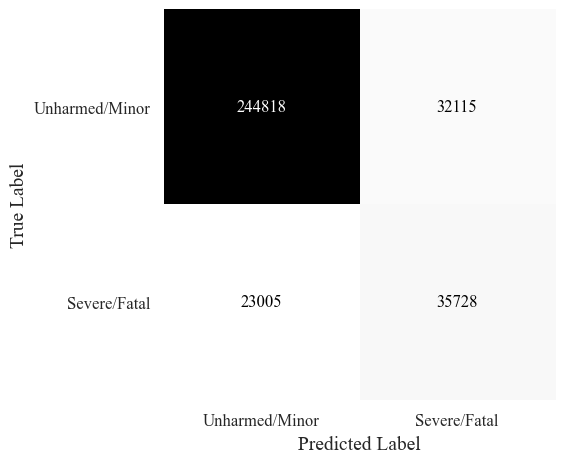

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Configurar fonte global para Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Gerar matriz de confusão
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots()

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Unharmed/Minor', 'Severe/Fatal']
)

disp.plot(
    cmap='Grays',  # Escolha de cores mais neutra para artigos
    values_format='d',
    ax=ax,
    colorbar=False  # opcional: remove barra lateral (mais comum em artigos)
)

# Ajustar tamanho das labels (eixos)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)

# Ajustar tamanho dos ticks
ax.tick_params(axis='both', which='major', labelsize=12)

# Remover título (regra do artigo)
ax.set_title('')

# Remover grid
ax.grid(False)

# Remover bordas extras (opcional, deixa mais limpo)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

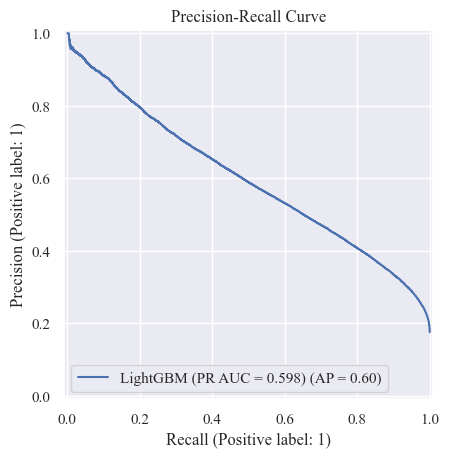

In [53]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

# Calculando a métrica PR-AUC (Average Precision)
# A variável proba já foi calculada por você como modelo.predict_proba(X_test)[:,1]
pr_auc = average_precision_score(y_test, proba)

disp_pr = PrecisionRecallDisplay.from_predictions(y_test, proba, name=f"LightGBM (PR AUC = {pr_auc:.3f})")
plt.title('Precision-Recall Curve')
plt.show()

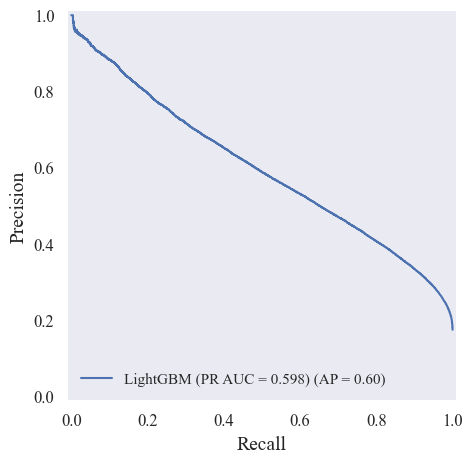

In [54]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
import matplotlib.pyplot as plt

# Fonte Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Calcular PR-AUC
pr_auc = average_precision_score(y_test, proba)

# Criar figura
fig, ax = plt.subplots()

# Plot
disp_pr = PrecisionRecallDisplay.from_predictions(
    y_test,
    proba,
    name=f"LightGBM (PR AUC = {pr_auc:.3f})",
    ax=ax
)

# Ajustar labels
ax.set_xlabel('Recall', fontsize=14)
ax.set_ylabel('Precision', fontsize=14)

# Ajustar ticks
ax.tick_params(axis='both', which='major', labelsize=12)

# Remover título (regra do artigo)
ax.set_title('')

# Remover grid
ax.grid(False)

# Remover caixa da legenda
legend = ax.get_legend()
if legend is not None:
    legend.set_frame_on(False)

# Remover bordas (opcional, visual mais limpo)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

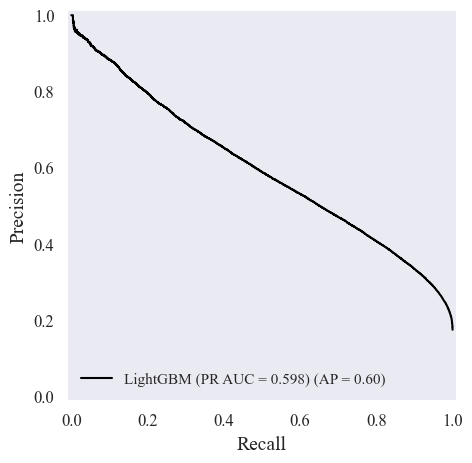

In [55]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'

pr_auc = average_precision_score(y_test, proba)

fig, ax = plt.subplots()

PrecisionRecallDisplay.from_predictions(
    y_test,
    proba,
    name=f"LightGBM (PR AUC = {pr_auc:.3f})",
    ax=ax,
    color='black'   # linha preta
)

ax.set_xlabel('Recall', fontsize=14)
ax.set_ylabel('Precision', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

ax.set_title('')
ax.grid(False)

# legenda sem caixa
legend = ax.get_legend()
if legend is not None:
    legend.set_frame_on(False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [56]:
# import pandas as pd
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import roc_auc_score

# # 1. Transformar as colunas de texto em numéricas (One-Hot Encoding)
# # O drop_first=True ajuda a evitar multicolinearidade (ótimo para Regressão Logística)
# X_train_encoded = pd.get_dummies(X_train, drop_first=True)
# X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# # 2. ALINHAMENTO DE COLUNAS (Passo de segurança crucial)
# # Garante que o X_test tenha exatamente as mesmas colunas do X_train.
# # Se um estado como 'AM' apareceu no treino mas não no teste, isso evita um erro.
# X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# # =====================================================================
# # Agora você treina passando os dados "_encoded" numéricos
# # =====================================================================

# # Treinando Logistic Regression
# baseline_lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
# baseline_lr.fit(X_train_encoded, y_train)
# proba_lr = baseline_lr.predict_proba(X_test_encoded)[:, 1]

# # Treinando Random Forest
# baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
# baseline_rf.fit(X_train_encoded, y_train)
# proba_rf = baseline_rf.predict_proba(X_test_encoded)[:, 1]

# # Imprimindo os resultados
# print(f"ROC AUC - Logistic Regression: {roc_auc_score(y_test, proba_lr):.4f}")
# print(f"ROC AUC - Random Forest: {roc_auc_score(y_test, proba_rf):.4f}")

Brier Score LightGBM: 0.1186


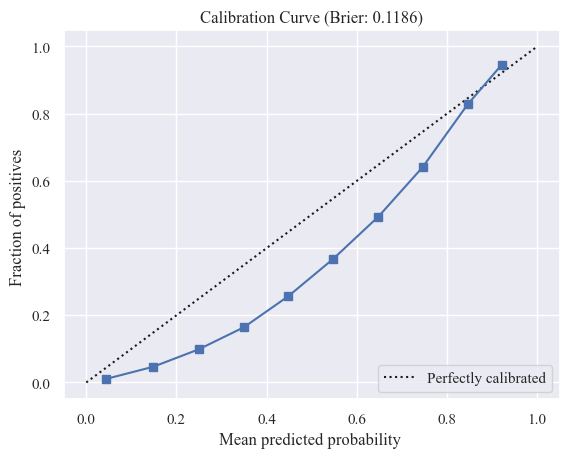

In [57]:
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.metrics import brier_score_loss

# Brier Score avalia o erro médio quadrado das probabilidades (quanto menor, melhor)
brier_lgbm = brier_score_loss(y_test, proba)
print(f"Brier Score LightGBM: {brier_lgbm:.4f}")

# Plotando a calibração
prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)
disp_calib = CalibrationDisplay(prob_true, prob_pred, proba)
disp_calib.plot()
plt.title(f'Calibration Curve (Brier: {brier_lgbm:.4f})')
plt.show()

In [58]:
import pandas as pd

importancia = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

print(importancia.head(15))

          feature  importance
11    tracado_via        6612
18     Fabricante        4622
2          km_bin        2736
14  idade_veiculo        2275
17       regional        2205
0              uf        2022
16      longitude        2011
6         dia_mes        1926
3            hora        1909
15       latitude        1886
5      dia_semana        1781
13   tipo_veiculo        1636
4             mes        1407
7   tipo_acidente        1340
1              br        1252


c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


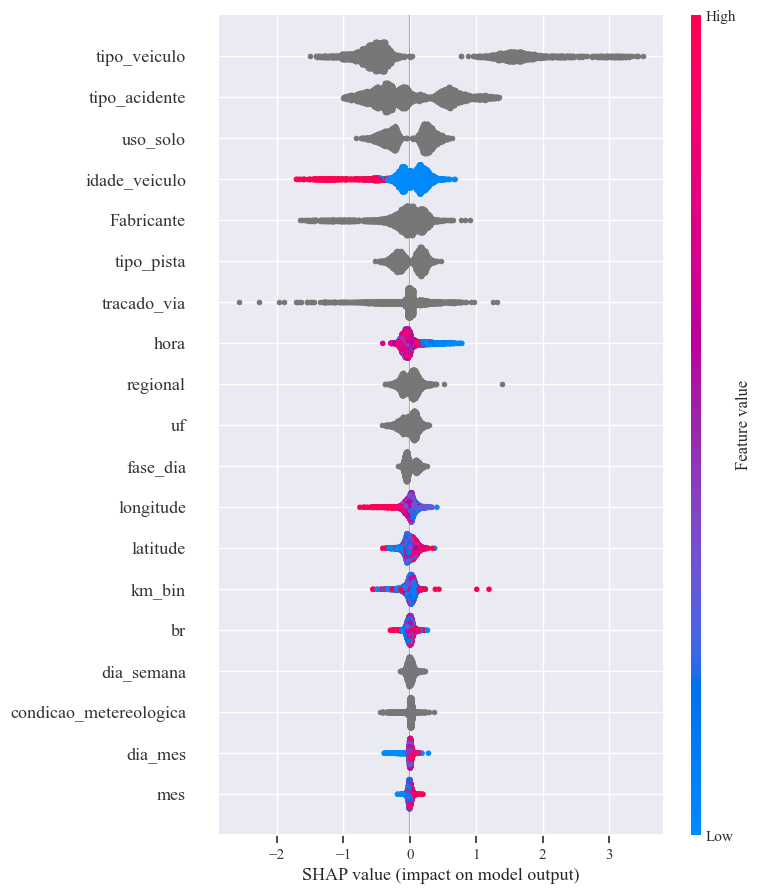

In [59]:
import shap

X_sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


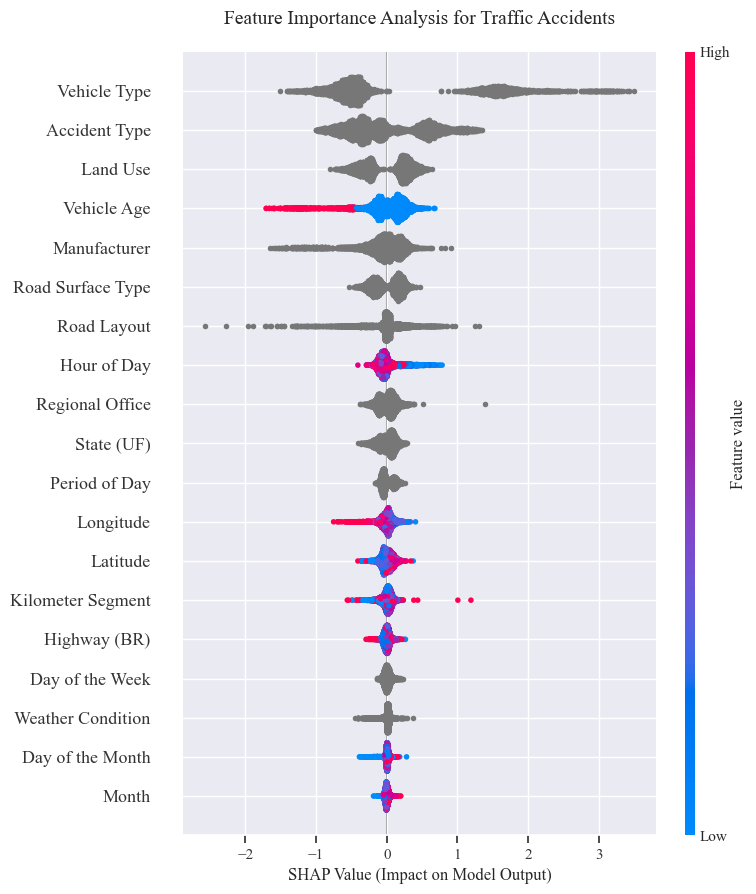

In [60]:
import shap
import matplotlib.pyplot as plt

# 1. Dicionário de Tradução (Baseado nas suas features)
translation_dict = {
    "uf": "State (UF)",
    "br": "Highway (BR)",
    "km_bin": "Kilometer Segment",
    "hora": "Hour of Day",
    "mes": "Month",
    "dia_semana": "Day of the Week",
    "dia_mes": "Day of the Month",
    "tipo_acidente": "Accident Type",
    "fase_dia": "Period of Day",
    "condicao_metereologica": "Weather Condition",
    "tipo_pista": "Road Surface Type",
    "tracado_via": "Road Layout",
    "uso_solo": "Land Use",
    "tipo_veiculo": "Vehicle Type",
    "idade_veiculo": "Vehicle Age",
    "latitude": "Latitude", 
    "longitude": "Longitude",
    "regional": "Regional Office", 
    "Fabricante": "Manufacturer"
}

# 2. Preparação dos dados (Amostra e Tradução)
# É importante traduzir o X_test antes de passar pelo explainer
X_test_en = X_test.rename(columns=translation_dict)
X_sample = X_test_en.sample(5000, random_state=42)

# 3. Execução do Explainer
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_sample)

# 4. Bloco de Plotagem
plt.figure(figsize=(10, 8)) # Ajuste o tamanho para o layout do artigo

# Se for classificação multiclasse, escolha a classe (ex: [1] para 'Grave')
# Se for regressão ou binário, use apenas: shap.summary_plot(shap_values, X_sample, show=False)
shap.summary_plot(shap_values, X_sample, show=False)

# Tradução dos labels dos eixos
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
plt.title("Feature Importance Analysis for Traffic Accidents", fontsize=14, pad=20)

# Salvar com alta resolução para o artigo
plt.tight_layout()
plt.savefig("shap_summary_english.png", dpi=300, bbox_inches='tight')
plt.show()

In [61]:
print("Shape inicial:", df.shape)

Shape inicial: (1678326, 58)


          feature  importance
11    tracado_via        6612
18     Fabricante        4622
2          km_bin        2736
14  idade_veiculo        2275
17       regional        2205
0              uf        2022
16      longitude        2011
6         dia_mes        1926
3            hora        1909
15       latitude        1886
5      dia_semana        1781
13   tipo_veiculo        1636
4             mes        1407
7   tipo_acidente        1340
1              br        1252


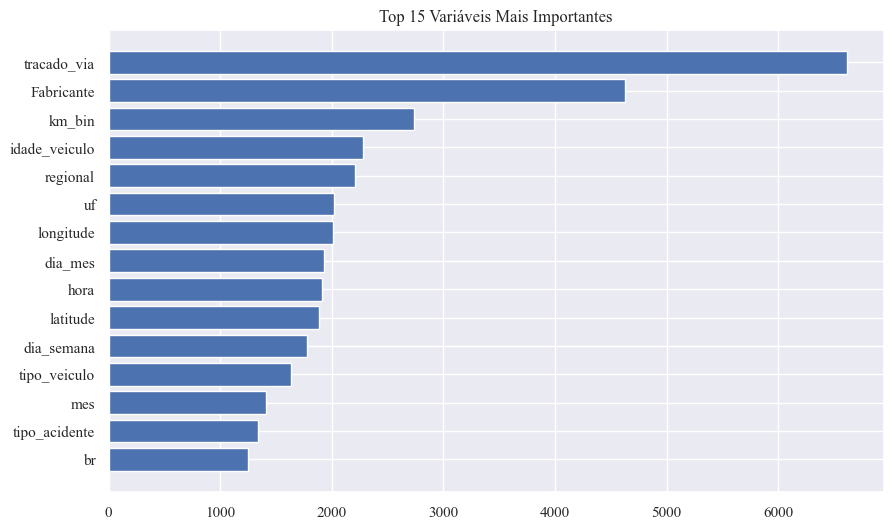

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

importancia = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

print(importancia.head(15))

plt.figure(figsize=(10,6))
plt.barh(importancia["feature"][:15][::-1], importancia["importance"][:15][::-1])
plt.title("Top 15 Variáveis Mais Importantes")
plt.show()

In [63]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

def rodar_pdp(
    modelo,
    X,
    nome_modelo="Modelo",
    sample_size=None
):
    if sample_size:
        X_plot = X.sample(sample_size, random_state=42)
    else:
        X_plot = X

    features = [
        ("hora", None),
        ("mes", None),  # no seu caso já é numérico
        ("dia_semana", ["dia_semana"]),
        ("idade_veiculo", None),
        ("tipo_pista", ["tipo_pista"]),
        ("fase_dia", ["fase_dia"]),
        ("condicao_metereologica", ["condicao_metereologica"]),
    ]

    for feature, cat in features:
        PartialDependenceDisplay.from_estimator(
            modelo,
            X_plot,
            [feature],
            categorical_features=cat,
            grid_resolution=50 if feature == "idade_veiculo" else 100,
            kind="average",
            response_method="predict_proba"  # 🔥 IMPORTANTE
        )

        plt.title(f"{nome_modelo} - Impacto de {feature}")
        plt.ylabel("Probabilidade de Acidente Grave")  # 🔥 importante

        if feature == "idade_veiculo":
            plt.xlim(0, 35)

        plt.show()

    # 🔥 interação por clima
    top_climas = X["condicao_metereologica"].value_counts().head(4).index

    for clima in top_climas:
        subset = X[X["condicao_metereologica"] == clima]

        if sample_size:
            subset = subset.sample(min(sample_size, len(subset)), random_state=42)

        PartialDependenceDisplay.from_estimator(
            modelo,
            subset,
            ["hora"],
            response_method="predict_proba"  # 🔥 aqui também
        )

        plt.title(f"{nome_modelo} - Risco por hora ({clima})")
        plt.ylabel("Probabilidade de Acidente Grave")
        plt.show()

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


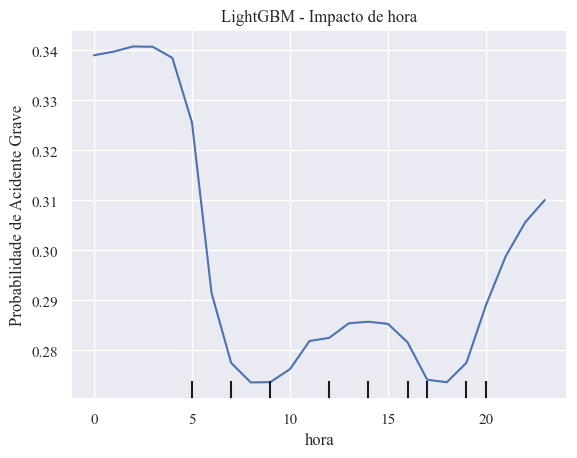

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


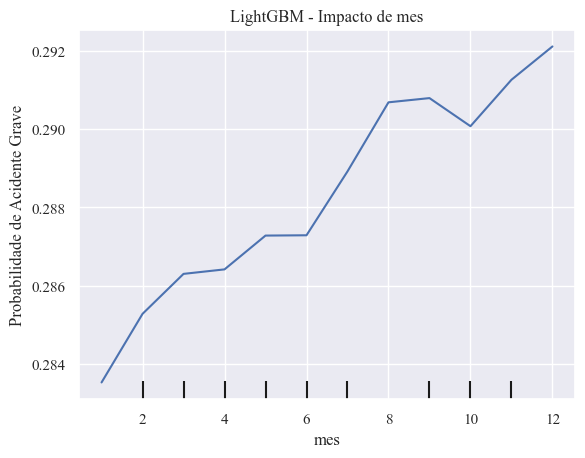

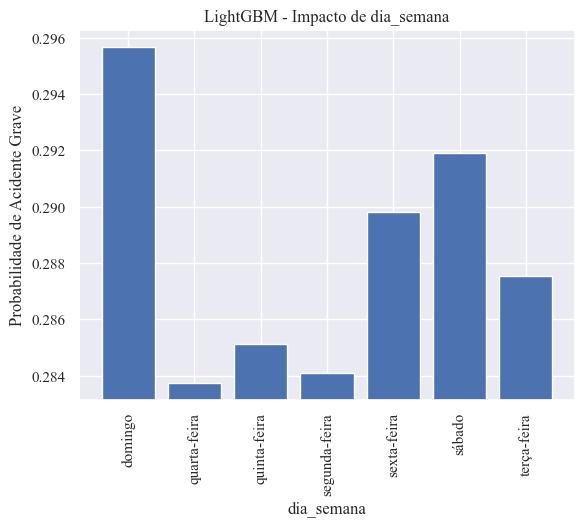

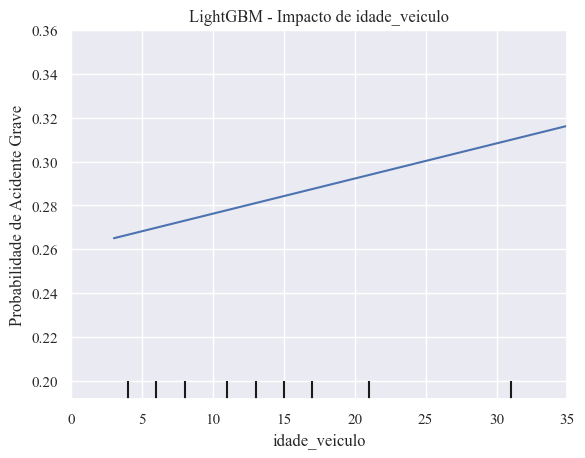

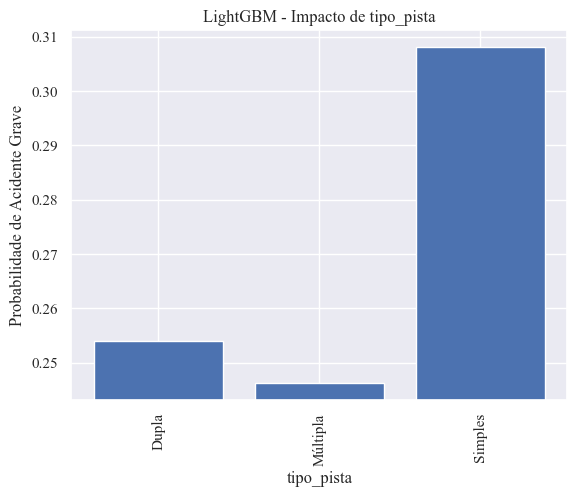

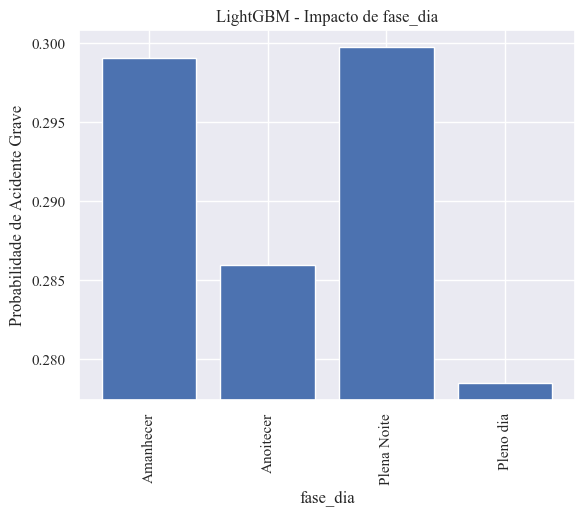

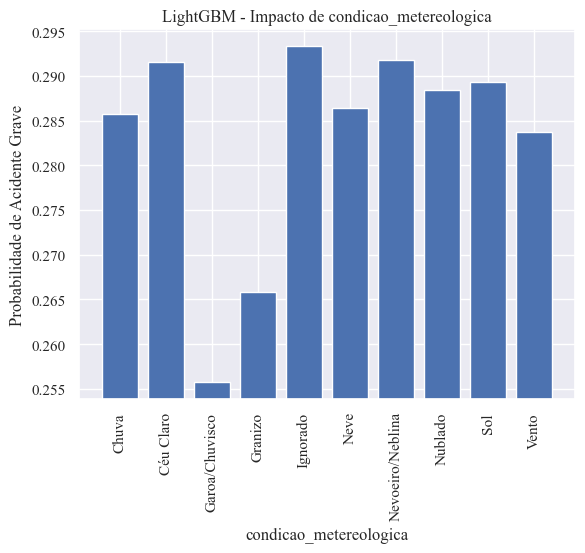

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


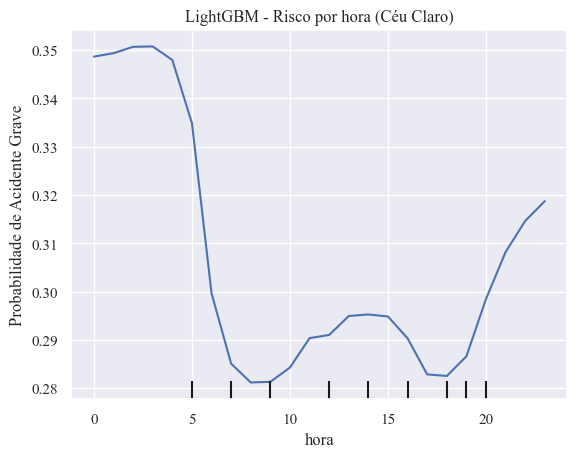

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


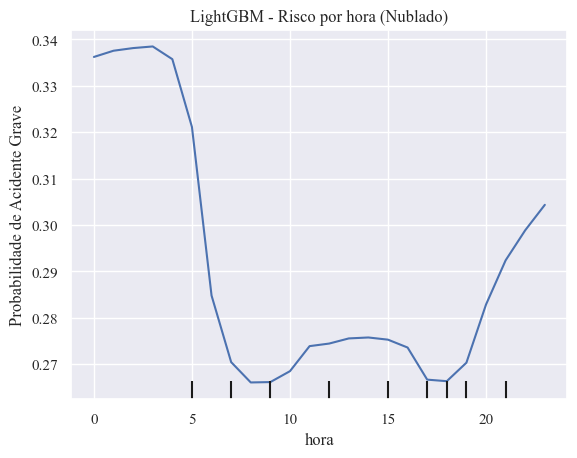

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


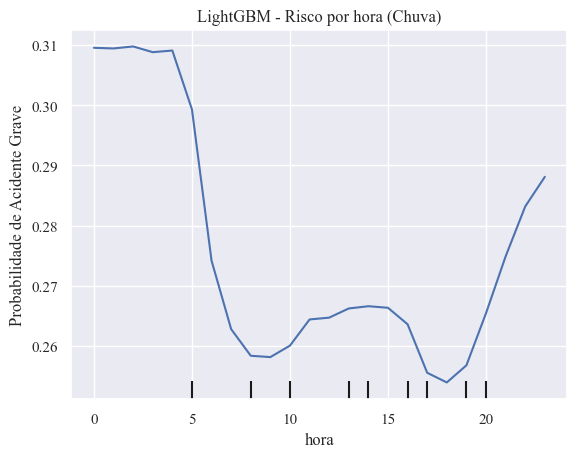

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


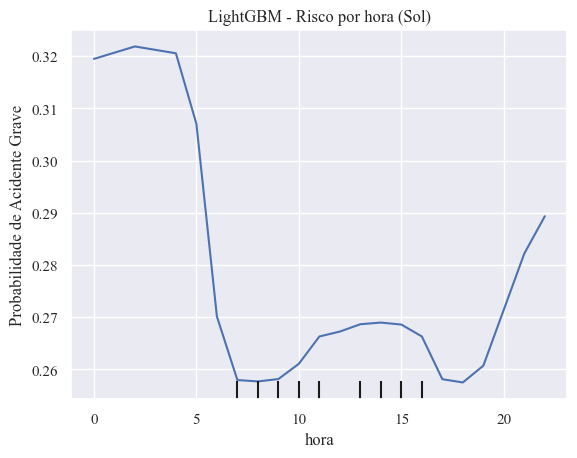

In [64]:
rodar_pdp(modelo, X_test, nome_modelo="LightGBM")

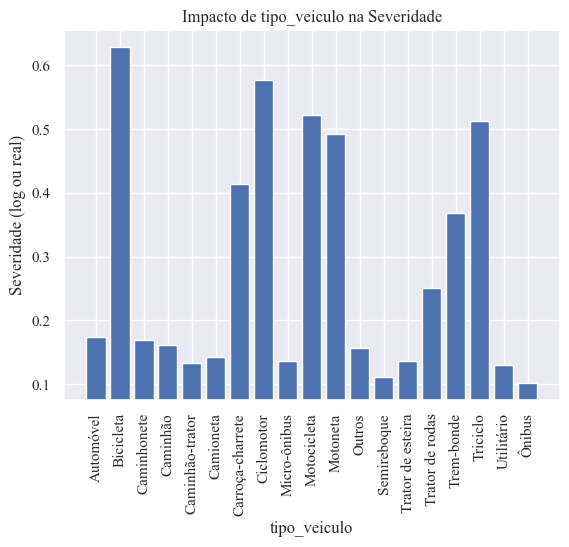

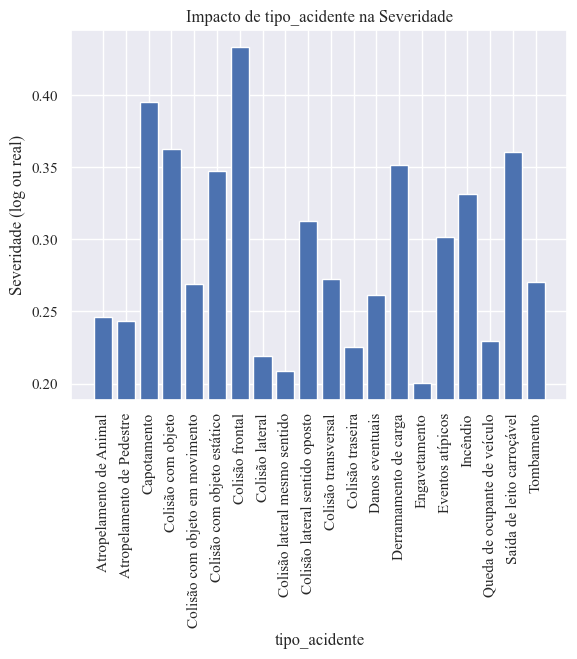

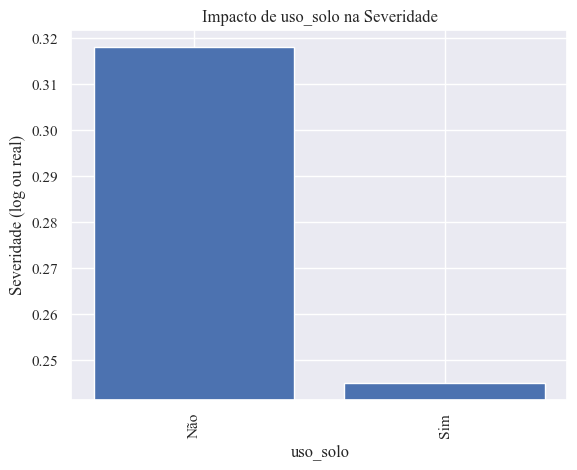

In [65]:
features_cat = ["tipo_veiculo", "tipo_acidente", "uso_solo"]

for feature in features_cat:
    
    PartialDependenceDisplay.from_estimator(
        modelo,
        X_test.sample(5000),
        [feature],
        categorical_features=[feature],
        kind="average"
    )

    plt.title(f"Impacto de {feature} na Severidade")
    plt.ylabel("Severidade (log ou real)")
    plt.show()

In [66]:
# import matplotlib.pyplot as plt
# import shap
# from sklearn.inspection import PartialDependenceDisplay

# # ==========================================================
# # 1. DICIONÁRIOS DE TRADUÇÃO (TECHNICAL TERMS)
# # ==========================================================

# map_features = {
#     "uf": "State (UF)", "br": "Highway (BR)", "km_bin": "Kilometer Segment",
#     "hora": "Hour of Day", "mes": "Month", "dia_semana": "Day of the Week",
#     "dia_mes": "Day of the Month", "tipo_acidente": "Accident Type",
#     "fase_dia": "Period of Day", "condicao_metereologica": "Weather Condition",
#     "tipo_pista": "Road Surface Type", "tracado_via": "Road Layout",
#     "uso_solo": "Land Use", "tipo_veiculo": "Vehicle Type",
#     "idade_veiculo": "Vehicle Age", "latitude": "Latitude", 
#     "longitude": "Longitude", "regional": "Regional Office", 
#     "Fabricante": "Manufacturer"
# }

# map_veiculo = {
#     'Automóvel': 'Car', 'Outros': 'Others', 'Caminhonete': 'Pickup Truck',
#     'Motocicleta': 'Motorcycle', 'Caminhão-trator': 'Tractor Truck',
#     'Motoneta': 'Scooter', 'Caminhão': 'Truck', 'Camioneta': 'SUV/Van',
#     'Micro-ônibus': 'Minibus', 'Bicicleta': 'Bicycle', 'Ônibus': 'Bus',
#     'Utilitário': 'Utility Vehicle', 'Ciclomotor': 'Moped', 'Semireboque': 'Semi-trailer',
#     'Trator de rodas': 'Wheel Tractor', 'Motor-casa': 'Motorhome', 'Reboque': 'Trailer',
#     'Carroça-charrete': 'Animal-drawn Cart', 'Chassi-plataforma': 'Chassis-platform',
#     'Trem-bonde': 'Train/Tram', 'Triciclo': 'Tricycle', 'Carro de mão': 'Handcart',
#     'Trator misto': 'Mixed Tractor', 'Quadriciclo': 'Quadricycle', 'Trator de esteira': 'Crawler Tractor'
# }

# map_acidente = {
#     'Saída de leito carroçável': 'Run-off-road', 'Atropelamento de Animal': 'Animal Collision',
#     'Atropelamento de Pedestre': 'Pedestrian Collision', 'Colisão lateral': 'Side Collision',
#     'Colisão com objeto estático': 'Fixed Object Collision', 'Tombamento': 'Overturning',
#     'Capotamento': 'Rollover', 'Colisão transversal': 'Cross-traffic Collision',
#     'Colisão frontal': 'Head-on Collision', 'Queda de ocupante de veículo': 'Fall from Vehicle',
#     'Incêndio': 'Fire', 'Colisão traseira': 'Rear-end Collision',
#     'Derramamento de carga': 'Cargo Spillage', 'Engavetamento': 'Pile-up',
#     'Colisão com objeto em movimento': 'Moving Object Collision', 'Danos eventuais': 'Accidental Damage',
#     'Colisão com objeto': 'Object Collision', 'Colisão lateral mesmo sentido': 'Same-direction Side',
#     'Colisão lateral sentido oposto': 'Opposite-direction Side', 'Eventos atípicos': 'Atypical Events',
#     'Sinistro pessoal de trânsito': 'Personal Incident'
# }

# map_uso_solo = {'Sim': 'Urban', 'Não': 'Rural'}

# # ==========================================================
# # 2. PREPARAÇÃO DOS DADOS (TRANSLATION & SAMPLING)
# # ==========================================================

# X_test_en = X_test.copy()
# X_test_en['tipo_veiculo'] = X_test_en['tipo_veiculo'].map(map_veiculo)
# X_test_en['tipo_acidente'] = X_test_en['tipo_acidente'].map(map_acidente)
# X_test_en['uso_solo'] = X_test_en['uso_solo'].map(map_uso_solo)
# X_test_en = X_test_en.rename(columns=map_features)

# X_sample_en = X_test_en.sample(5000, random_state=42)

# # ==========================================================
# # 3. BLOCO SHAP SUMMARY PLOT
# # ==========================================================

# explainer = shap.TreeExplainer(modelo)
# shap_values = explainer.shap_values(X_sample_en)

# plt.figure(figsize=(10, 8))
# # Se for multiclasse, use shap_values[1] (ou a classe alvo)
# shap.summary_plot(shap_values, X_sample_en, show=False)
# plt.xlabel("SHAP Value (Impact on Severity Index)", fontsize=12)
# plt.title("Feature Importance - SHAP Analysis", fontsize=14, pad=20)
# plt.savefig("shap_summary_en.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ==========================================================
# # 4. BLOCO PARTIAL DEPENDENCE PLOTS (PDP)
# # ==========================================================

# features_cat_en = ["Vehicle Type", "Accident Type", "Land Use"]

# for feature in features_cat_en:
#     fig, ax = plt.subplots(figsize=(12, 7))
    
#     PartialDependenceDisplay.from_estimator(
#         modelo,
#         X_sample_en,
#         [feature],
#         categorical_features=[feature],
#         kind="average",
#         ax=ax
#     )

#     plt.title(f"Partial Dependence of {feature} on Severity", fontsize=14)
#     plt.ylabel("Partial Dependence (Model Output)", fontsize=12)
#     plt.xlabel(feature, fontsize=12)
#     plt.xticks(rotation=45, ha='right')
    
#     plt.tight_layout()
#     plt.savefig(f"pdp_{feature.replace(' ', '_').lower()}.png", dpi=300)
#     plt.show()

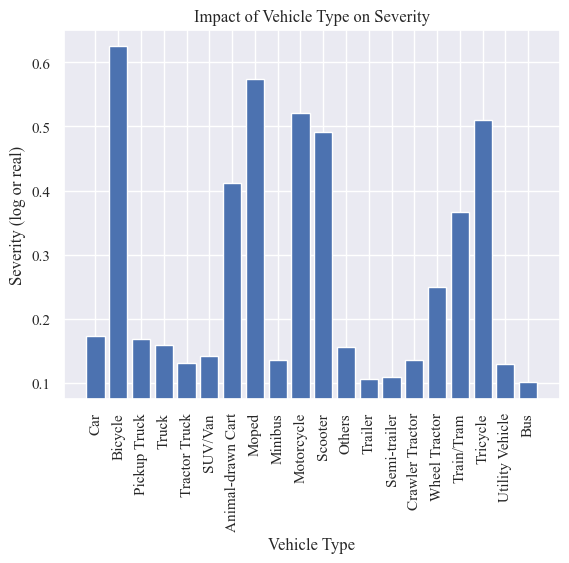

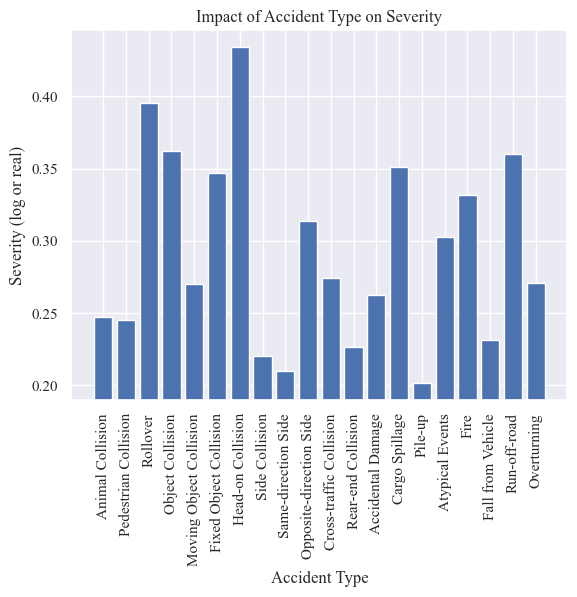

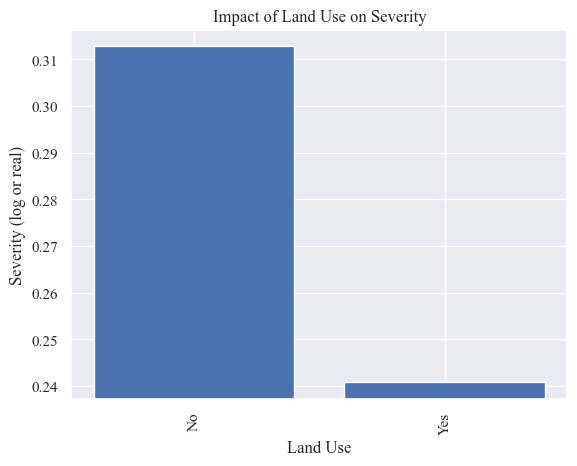

In [67]:
import matplotlib.pyplot as plt

# 1. Seus mapeamentos originais
map_veiculo = {
    'Automóvel': 'Car', 'Outros': 'Others', 'Caminhonete': 'Pickup Truck',
    'Motocicleta': 'Motorcycle', 'Caminhão-trator': 'Tractor Truck',
    'Motoneta': 'Scooter', 'Caminhão': 'Truck', 'Camioneta': 'SUV/Van',
    'Micro-ônibus': 'Minibus', 'Bicicleta': 'Bicycle', 'Ônibus': 'Bus',
    'Utilitário': 'Utility Vehicle', 'Ciclomotor': 'Moped', 'Semireboque': 'Semi-trailer',
    'Trator de rodas': 'Wheel Tractor', 'Motor-casa': 'Motorhome', 'Reboque': 'Trailer',
    'Carroça-charrete': 'Animal-drawn Cart', 'Chassi-plataforma': 'Chassis-platform',
    'Trem-bonde': 'Train/Tram', 'Triciclo': 'Tricycle', 'Carro de mão': 'Handcart',
    'Trator misto': 'Mixed Tractor', 'Quadriciclo': 'Quadricycle', 'Trator de esteira': 'Crawler Tractor'
}

map_acidente = {
    'Saída de leito carroçável': 'Run-off-road', 'Atropelamento de Animal': 'Animal Collision',
    'Atropelamento de Pedestre': 'Pedestrian Collision', 'Colisão lateral': 'Side Collision',
    'Colisão com objeto estático': 'Fixed Object Collision', 'Tombamento': 'Overturning',
    'Capotamento': 'Rollover', 'Colisão transversal': 'Cross-traffic Collision',
    'Colisão frontal': 'Head-on Collision', 'Queda de ocupante de veículo': 'Fall from Vehicle',
    'Incêndio': 'Fire', 'Colisão traseira': 'Rear-end Collision',
    'Derramamento de carga': 'Cargo Spillage', 'Engavetamento': 'Pile-up',
    'Colisão com objeto em movimento': 'Moving Object Collision', 'Danos eventuais': 'Accidental Damage',
    'Colisão com objeto': 'Object Collision', 'Colisão lateral mesmo sentido': 'Same-direction Side',
    'Colisão lateral sentido oposto': 'Opposite-direction Side', 'Eventos atípicos': 'Atypical Events',
    'Sinistro pessoal de trânsito': 'Personal Incident'
}

map_uso_solo = {'Sim': 'Yes', 'Não': 'No'} # Deixei o Y e N maiúsculos para o gráfico ficar mais formal

# 2. Mapeamento dos nomes das colunas (features)
feature_translations = {
    "tipo_veiculo": "Vehicle Type",
    "tipo_acidente": "Accident Type",
    "uso_solo": "Land Use"
}

# 3. Criamos um super dicionário relacionando a coluna ao seu respectivo mapeamento
traducoes_por_coluna = {
    "tipo_veiculo": map_veiculo,
    "tipo_acidente": map_acidente,
    "uso_solo": map_uso_solo
}

features_cat = ["tipo_veiculo", "tipo_acidente", "uso_solo"]

for feature in features_cat:
    
    # Gera o gráfico original baseado no modelo em PT
    display = PartialDependenceDisplay.from_estimator(
        modelo,
        X_test.sample(5000),
        [feature],
        categorical_features=[feature],
        kind="average"
    )

    ax = plt.gca()
    
    # Traduz o nome da Feature no eixo X
    feature_en = feature_translations.get(feature, feature)
    ax.set_xlabel(feature_en)
    
    # Identifica qual dicionário de categorias usar para a feature atual
    dicionario_atual = traducoes_por_coluna.get(feature, {})
    
    # Captura os rótulos em PT do gráfico e traduz usando o dicionário específico
    ticks = ax.get_xticks()
    old_labels = [label.get_text() for label in ax.get_xticklabels()]
    new_labels = [dicionario_atual.get(label, label) for label in old_labels]
    
    # Aplica as alterações de texto no eixo X
    ax.set_xticks(ticks)
    ax.set_xticklabels(new_labels)

    # Configura os títulos finais em Inglês
    plt.title(f"Impact of {feature_en} on Severity")
    plt.ylabel("Severity (log or real)")
    
    plt.show()

<Figure size 300x300 with 0 Axes>

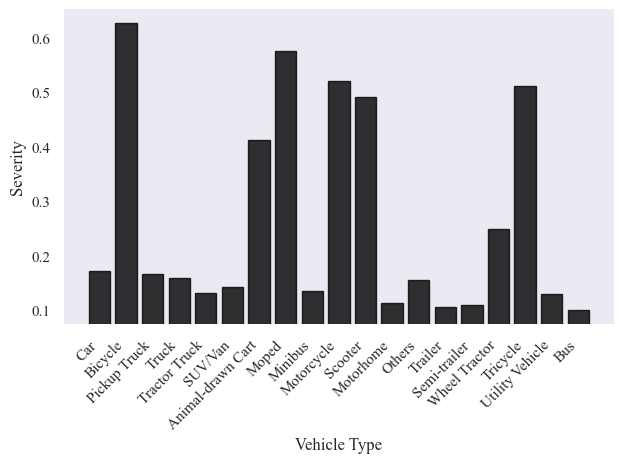

<Figure size 300x300 with 0 Axes>

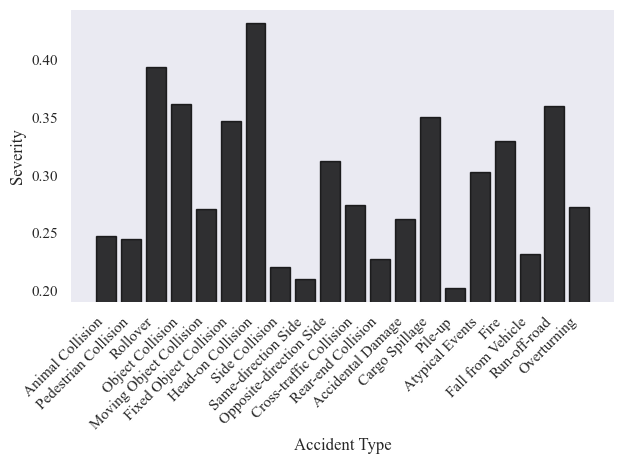

<Figure size 300x300 with 0 Axes>

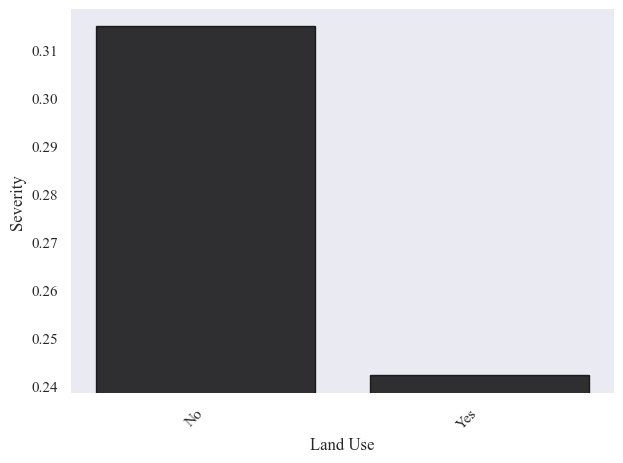

In [68]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

plt.rcParams['font.family'] = 'Times New Roman'

features_cat = ["tipo_veiculo", "tipo_acidente", "uso_solo"]

for feature in features_cat:
    
    plt.figure(figsize=(3, 3))
    
    display = PartialDependenceDisplay.from_estimator(
        modelo,
        X_test.sample(5000),
        [feature],
        categorical_features=[feature],
        kind="average"
    )
    
    ax = plt.gca()
    
    # =============================
    # Tradução
    # =============================
    feature_en = feature_translations.get(feature, feature)
    ax.set_xlabel(feature_en)
    
    dicionario_atual = traducoes_por_coluna.get(feature, {})
    
    ticks = ax.get_xticks()
    old_labels = [label.get_text() for label in ax.get_xticklabels()]
    new_labels = [dicionario_atual.get(label, label) for label in old_labels]
    
    ax.set_xticks(ticks)
    ax.set_xticklabels(new_labels, rotation=45, ha='right')
    
    ax.set_ylabel("Severity")
    ax.set_title("")
    ax.grid(False)
    
    for spine in ax.spines.values():
        spine.set_visible(False)

    # =============================
    # 🔥 PRETO E BRANCO
    # =============================
    
    # Caso 1: barras (categorical PDP costuma vir como bar plot)
    for patch in ax.patches:
        patch.set_facecolor("black")
        patch.set_edgecolor("black")
        patch.set_alpha(0.8)  # opcional, dá um cinza-escuro
    
    # Caso 2: linhas (caso venha como line plot)
    for line in ax.lines:
        line.set_color("black")
        line.set_linestyle("-")
        line.set_marker("o")  # opcional, ajuda a diferenciar pontos sem cor
    
    # Caso existam barras de erro / preenchimentos (fill_between)
    for coll in ax.collections:
        coll.set_facecolor("black")
        coll.set_edgecolor("black")
        coll.set_alpha(0.3)  # preenchimentos ficam cinza claro, não sólido

    plt.tight_layout()
    plt.savefig(f"pdp_{feature}.pdf", bbox_inches='tight')
    plt.show()